# Student Placement & Salary Prediction (Dataset B)

---

### Video Link:

---

## EDA + Modeling

**Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import pickle
import joblib
from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import SVR

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, mean_absolute_error, mean_squared_error, r2_score)

**Load Dataset**

In [ ]:
df = pd.read_csv("B.csv")
df.head()

,student_id,gender,ssc_percentage,hsc_percentage,degree_percentage,cgpa,entrance_exam_score,technical_skill_score,soft_skill_score,internship_count,live_projects,work_experience_months,certifications,attendance_percentage,backlogs,extracurricular_activities,placement_status,salary_package_lpa
0,1,Male,53,79,56,8.87,50,92,90,1,3,23,4,91,4,Yes,0,0.00
1,2,Female,56,54,59,6.78,61,51,99,1,0,6,5,87,3,No,0,0.00
2,3,Male,94,83,83,7.92,91,93,84,1,1,10,2,81,2,No,1,6.92
3,4,Male,84,71,87,6.57,85,60,72,4,2,14,5,87,3,No,0,0.00
4,5,Male,58,88,74,9.01,73,52,88,1,2,20,0,60,1,No,0,0.00


**Dataset Overview**

In [ ]:
df.shape

(5000, 18)

In [ ]:
df.columns

Index(['student_id', 'gender', 'ssc_percentage', 'hsc_percentage',
       'degree_percentage', 'cgpa', 'entrance_exam_score',
       'technical_skill_score', 'soft_skill_score', 'internship_count',
       'live_projects', 'work_experience_months', 'certifications',
       'attendance_percentage', 'backlogs', 'extracurricular_activities',
       'placement_status', 'salary_package_lpa'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  5000 non-null   int64  
 1   gender                      5000 non-null   object 
 2   ssc_percentage              5000 non-null   int64  
 3   hsc_percentage              5000 non-null   int64  
 4   degree_percentage           5000 non-null   int64  
 5   cgpa                        5000 non-null   float64
 6   entrance_exam_score         5000 non-null   int64  
 7   technical_skill_score       5000 non-null   int64  
 8   soft_skill_score            5000 non-null   int64  
 9   internship_count            5000 non-null   int64  
 10  live_projects               5000 non-null   int64  
 11  work_experience_months      5000 non-null   int64  
 12  certifications              5000 non-null   int64  
 13  attendance_percentage       5000 

In [ ]:
df.describe()

,student_id,ssc_percentage,hsc_percentage,degree_percentage,cgpa,entrance_exam_score,technical_skill_score,soft_skill_score,internship_count,live_projects,work_experience_months,certifications,attendance_percentage,backlogs,placement_status,salary_package_lpa
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000
mean,2500.500000,72.425800,71.910800,71.845200,7.678326,69.197800,69.651000,69.839600,1.987800,2.491800,11.982000,2.481000,79.433400,2.518400,0.173200,1.59589
std,1443.520003,13.199642,12.842781,10.013196,1.237084,17.325528,17.179704,17.170732,1.410975,1.704967,7.258114,1.719485,11.638585,1.721004,0.378458,3.77582
min,1.000000,50.000000,50.000000,55.000000,5.500000,40.000000,40.000000,40.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,0.000000,0.00000
25%,1250.750000,61.000000,61.000000,63.000000,6.617500,54.000000,55.000000,55.000000,1.000000,1.000000,6.000000,1.000000,69.000000,1.000000,0.000000,0.00000
50%,2500.500000,72.000000,72.000000,72.000000,7.700000,69.000000,70.000000,69.000000,2.000000,3.000000,12.000000,2.000000,80.000000,3.000000,0.000000,0.00000
75%,3750.250000,84.000000,83.000000,80.000000,8.750000,84.000000,84.000000,85.000000,3.000000,4.000000,18.000000,4.000000,89.000000,4.000000,0.000000,0.00000
max,5000.000000,95.000000,94.000000,89.000000,9.800000,99.000000,99.000000,99.000000,4.000000,5.000000,24.000000,5.000000,99.000000,5.000000,1.000000,14.99000


**EDA**

Duplicate Data

In [ ]:
print("Duplicates: ", df.duplicated().sum())

Duplicates:  0


Drop Identifier

In [ ]:
df = df.drop(columns=['student_id'])

Data Types

In [ ]:
df.dtypes

,0
gender,object
ssc_percentage,int64
hsc_percentage,int64
degree_percentage,int64
cgpa,float64
entrance_exam_score,int64
technical_skill_score,int64
soft_skill_score,int64
internship_count,int64
live_projects,int64


Fix Data Types

In [ ]:
percentage_cols = ['ssc_percentage', 'hsc_percentage', 'degree_percentage', 'attendance_percentage', 'entrance_exam_score']
df[percentage_cols] = df[percentage_cols].astype(float)

Missing Values

In [ ]:
df.isnull().sum()

,0
gender,0
ssc_percentage,0
hsc_percentage,0
degree_percentage,0
cgpa,0
entrance_exam_score,0
technical_skill_score,0
soft_skill_score,0
internship_count,0
live_projects,0


Unique Value

In [ ]:
for col in df.columns:
    print(f"\nCOLUMN: {col}")
    print(df[col].value_counts(dropna=False))


COLUMN: gender
gender
Male      2504
Female    2496
Name: count, dtype: int64

COLUMN: ssc_percentage
ssc_percentage
75.0    129
72.0    128
62.0    127
66.0    126
94.0    125
91.0    123
67.0    121
65.0    119
78.0    117
51.0    115
77.0    115
81.0    115
87.0    113
53.0    112
64.0    112
61.0    111
71.0    111
52.0    111
68.0    110
89.0    109
69.0    108
74.0    108
84.0    107
54.0    107
70.0    107
88.0    107
85.0    106
93.0    105
59.0    105
83.0    105
55.0    104
92.0    103
50.0    103
56.0    102
58.0    102
79.0    102
73.0    101
60.0    100
86.0     99
57.0     99
63.0     98
80.0     97
90.0     96
95.0     95
76.0     95
82.0     90
Name: count, dtype: int64

COLUMN: hsc_percentage
hsc_percentage
62.0    136
65.0    134
82.0    129
66.0    129
78.0    124
68.0    122
75.0    122
73.0    120
91.0    119
72.0    119
93.0    119
86.0    119
59.0    119
80.0    118
92.0    117
71.0    115
77.0    115
56.0    115
58.0    114
61.0    113
74.0    112
67.0    111
5

Univariate Analysis

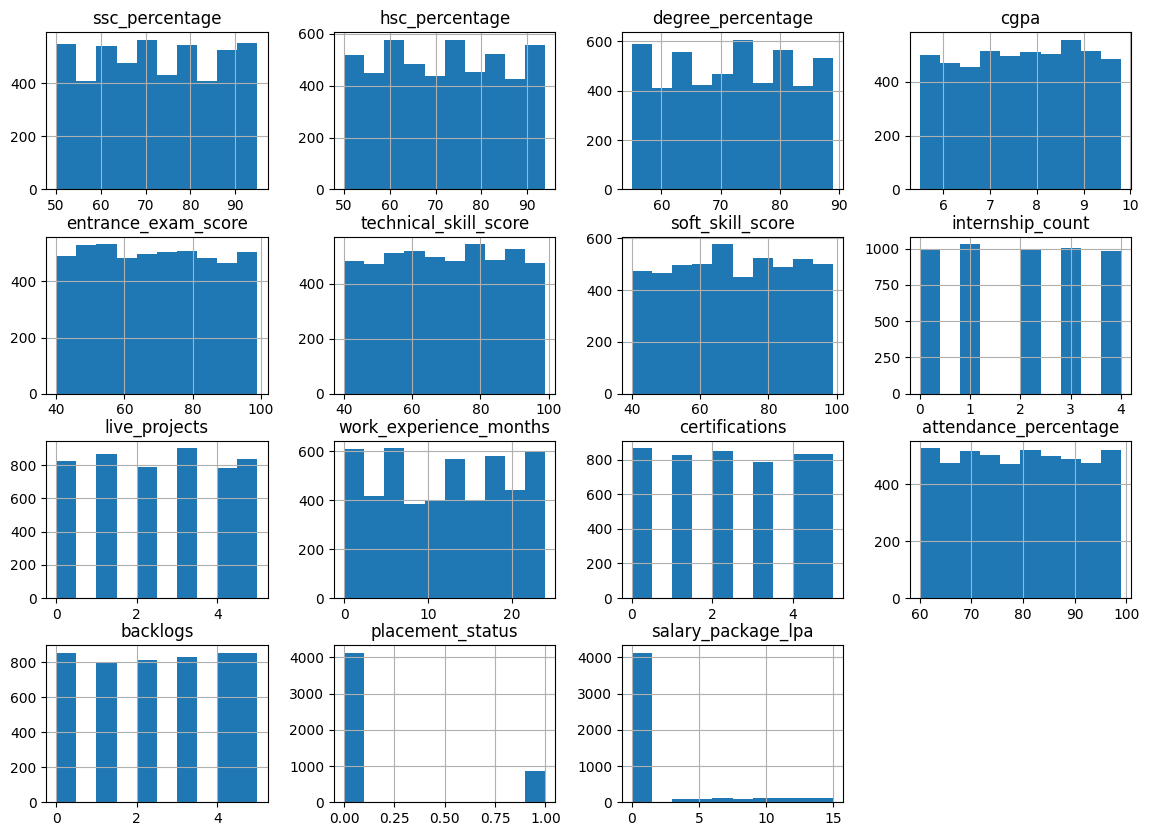

In [ ]:
df.hist(figsize=(14,10))
plt.show()

Identify Target

In [ ]:
target_class = "placement_status"
target_reg = "salary_package_lpa"

X = df.drop(columns=[target_class, target_reg])
y_class = df[target_class]
y_reg = df[target_reg]

Target Distribution

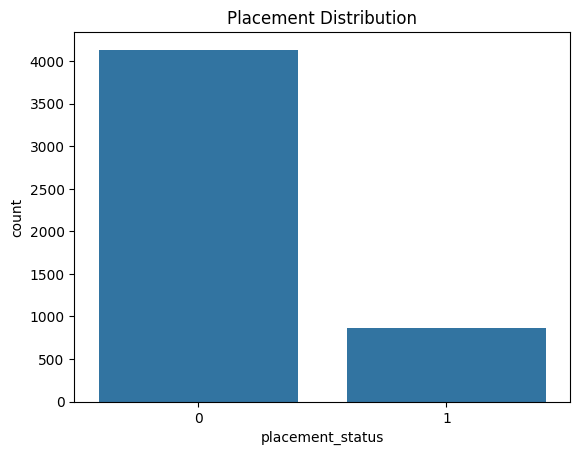

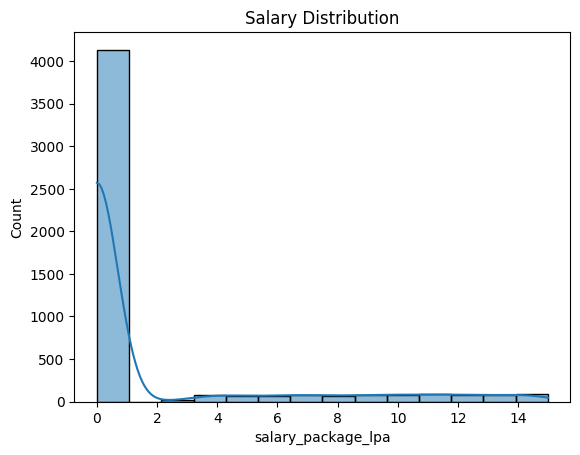

In [ ]:
sns.countplot(x=y_class)
plt.title("Placement Distribution")
plt.show()

sns.histplot(y_reg, kde=True)
plt.title("Salary Distribution")
plt.show()

In [ ]:
df[target_class].value_counts()
df[target_reg].describe()

,salary_package_lpa
count,5000.00000
mean,1.59589
std,3.77582
min,0.00000
25%,0.00000
50%,0.00000
75%,0.00000
max,14.99000


Correlation Analysis

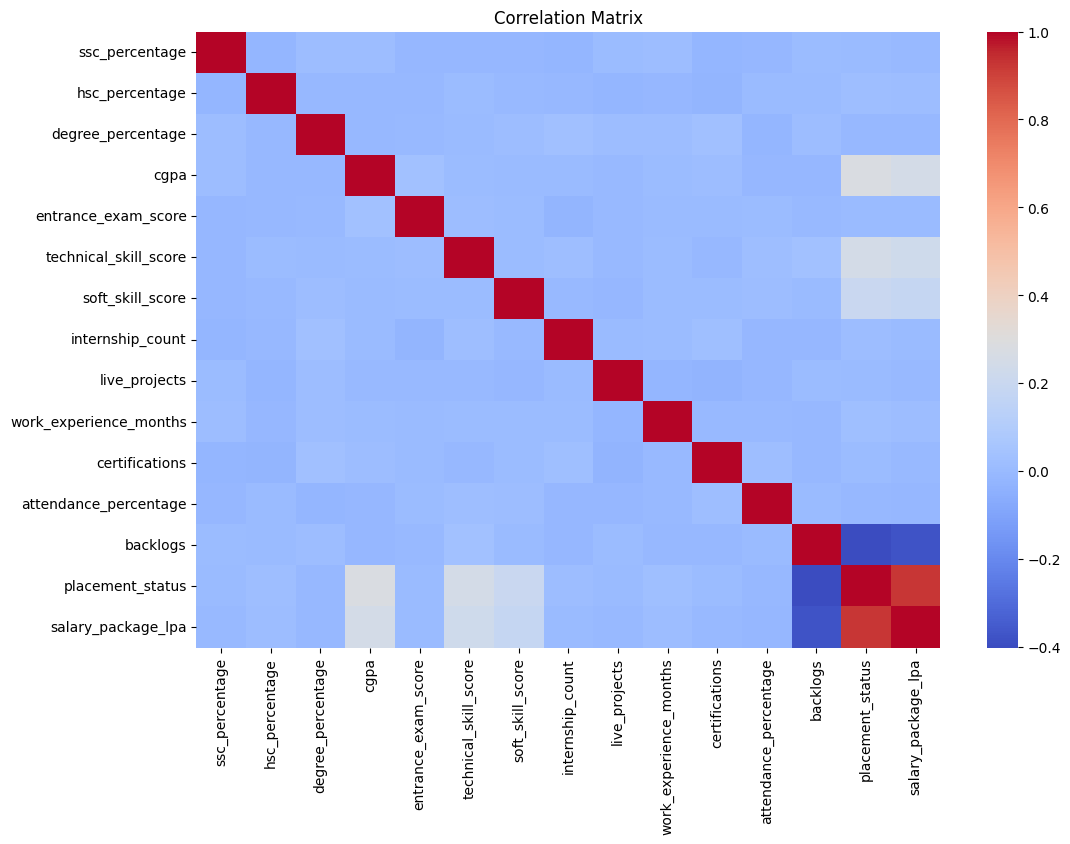

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [ ]:
df.corr(numeric_only=True)[target_class].sort_values()
df.corr(numeric_only=True)[target_reg].sort_values()

,salary_package_lpa
backlogs,-0.376909
attendance_percentage,-0.014698
degree_percentage,-0.009829
live_projects,-0.003859
certifications,-0.003365
ssc_percentage,-0.002207
entrance_exam_score,-0.001009
internship_count,0.003564
hsc_percentage,0.012632
work_experience_months,0.013853


Feature Engineering

In [ ]:
df['academic_score'] = (
    df['ssc_percentage'] +
    df['hsc_percentage'] +
    df['degree_percentage']
) / 3

df['skill_score'] = (
    df['technical_skill_score'] +
    df['soft_skill_score']
) / 2

df['engagement_score'] = (
    df['internship_count'] +
    df['live_projects'] +
    df['certifications']
)

Outliers

In [ ]:
def detect_iqr_outliers(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return data[(data[col] < lower) | (data[col] > upper)]

outliers_dict = {}

for col in numeric_cols:
    outliers_dict[col] = len(detect_iqr_outliers(df, col))

outliers_dict

{'ssc_percentage': 0,
 'hsc_percentage': 0,
 'degree_percentage': 0,
 'cgpa': 0,
 'entrance_exam_score': 0,
 'technical_skill_score': 0,
 'soft_skill_score': 0,
 'internship_count': 0,
 'live_projects': 0,
 'work_experience_months': 0,
 'certifications': 0,
 'attendance_percentage': 0,
 'backlogs': 0,
 'academic_score': 4,
 'skill_score': 0,
 'engagement_score': 0}

In [ ]:
iso = IsolationForest(contamination=0.05, random_state=42)

df['anomaly'] = iso.fit_predict(df[numeric_cols])
df['anomaly'].value_counts()

,count
anomaly,
1,4750
-1,250


In [ ]:
df = df[df['anomaly'] == 1]
df = df.drop(columns=['anomaly'])

Column Transformer (Encoding + Scaling)

In [ ]:
categorical_cols = ['gender', 'extracurricular_activities']
numeric_cols = [col for col in df.columns if col not in categorical_cols
                and col not in ['placement_status', 'salary_package_lpa']]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical_cols),
        ('num', StandardScaler(), numeric_cols)
    ]
)

In [ ]:
X = df.drop(['placement_status', 'salary_package_lpa'], axis=1)

y_cls = df['placement_status']
y_reg = df['salary_package_lpa']

X_processed = preprocessor.fit_transform(X)

**Split Dataset**

In [ ]:
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X, y_cls, test_size=0.2, random_state=42
)

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

**Modeling - Classification**

Logistic Regression

In [ ]:
log_model = Pipeline([
    ('preprocess', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

log_model.fit(X_train_cls, y_train_cls)
pred_log = log_model.predict(X_test_cls)

Random Forest Classifier

In [ ]:
rf_model = Pipeline([
    ('preprocess', preprocessor),
    ('model', RandomForestClassifier())
])

rf_model.fit(X_train_cls, y_train_cls)
pred_rf = rf_model.predict(X_test_cls)

KNN Classifier

In [ ]:
knn_model = Pipeline([
    ('preprocess', preprocessor),
    ('model', KNeighborsClassifier())
])

knn_model.fit(X_train_cls, y_train_cls)
pred_knn = knn_model.predict(X_test_cls)

Evaluate

In [ ]:
print("Logistic:", accuracy_score(y_test_cls, pred_log))
print("Random Forest:", accuracy_score(y_test_cls, pred_rf))
print("KNN:", accuracy_score(y_test_cls, pred_knn))

print(classification_report(y_test_cls, pred_log))

Logistic: 0.888421052631579
Random Forest: 1.0
KNN: 0.8957894736842106
              precision    recall  f1-score   support

           0       0.92      0.95      0.93       796
           1       0.69      0.56      0.62       154

    accuracy                           0.89       950
   macro avg       0.81      0.76      0.78       950
weighted avg       0.88      0.89      0.88       950



**Modeling - Regression**

Linear Regression

In [ ]:
lr_model = Pipeline([
    ('preprocess', preprocessor),
    ('model', LinearRegression())
])

lr_model.fit(X_train_reg, y_train_reg)
pred_lr = lr_model.predict(X_test_reg)

Random Forest Regressor

In [ ]:
rf_reg_model = Pipeline([
    ('preprocess', preprocessor),
    ('model', RandomForestRegressor())
])

rf_reg_model.fit(X_train_reg, y_train_reg)
pred_rf_reg = rf_reg_model.predict(X_test_reg)

SVR

In [ ]:
svr_model = Pipeline([
    ('preprocess', preprocessor),
    ('model', SVR())
])

svr_model.fit(X_train_reg, y_train_reg)
pred_svr = svr_model.predict(X_test_reg)

Evaluate

In [ ]:
print("Linear MAE:", mean_absolute_error(y_test_reg, pred_lr))
print("RF MAE:", mean_absolute_error(y_test_reg, pred_rf_reg))
print("SVR MAE:", mean_absolute_error(y_test_reg, pred_svr))

print("Linear MSE:", mean_squared_error(y_test_reg, pred_lr))
print("RF MSE:", mean_squared_error(y_test_reg, pred_rf_reg))
print("SVR MSE:", mean_squared_error(y_test_reg, pred_svr))

print("Linear R2:", r2_score(y_test_reg, pred_lr))
print("RF R2:", r2_score(y_test_reg, pred_rf_reg))
print("SVR R2:", r2_score(y_test_reg, pred_svr))

Linear MAE: 2.2316115747993486
RF MAE: 0.5101703157894737
SVR MAE: 1.311180968052896
Linear MSE: 9.377426600198579
RF MSE: 2.1587485384421057
SVR MSE: 8.116614104783332
Linear R2: 0.2484408005719282
RF R2: 0.8269858680329514
SVR R2: 0.3494893366023917


---

#### **Hyperparameter Tuning**

---

**Model Classification**

Logistic Regression + GridSearch

In [ ]:
log_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

log_param = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__solver': ['lbfgs', 'liblinear']
}

log_grid = GridSearchCV(log_pipe, log_param, cv=5, scoring='accuracy')
log_grid.fit(X_train_cls, y_train_cls)

best_log = log_grid.best_estimator_
pred_log = best_log.predict(X_test_cls)

Random Forest Classifier + GridSearch

In [ ]:
rf_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('model', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

rf_param = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5],
    'model__class_weight': ['balanced']
}

rf_grid = GridSearchCV(rf_pipe, rf_param, cv=5, scoring='accuracy')
rf_grid.fit(X_train_cls, y_train_cls)

best_rf = rf_grid.best_estimator_
pred_rf = best_rf.predict(X_test_cls)

KNN + GridSearch

In [ ]:
knn_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('model', KNeighborsClassifier())
])

knn_param = {
    'model__n_neighbors': [3, 5, 7, 9],
    'model__weights': ['uniform', 'distance']
}

knn_grid = GridSearchCV(knn_pipe, knn_param, cv=5, scoring='accuracy')
knn_grid.fit(X_train_cls, y_train_cls)

best_knn = knn_grid.best_estimator_
pred_knn = best_knn.predict(X_test_cls)

Evaluate

In [ ]:
print("Logistic:", accuracy_score(y_test_cls, pred_log))
print("Random Forest:", accuracy_score(y_test_cls, pred_rf))
print("KNN:", accuracy_score(y_test_cls, pred_knn))

print(classification_report(y_test_cls, pred_log))

Logistic: 0.8905263157894737
Random Forest: 1.0
KNN: 0.9031578947368422
              precision    recall  f1-score   support

           0       0.92      0.95      0.94       796
           1       0.70      0.56      0.62       154

    accuracy                           0.89       950
   macro avg       0.81      0.76      0.78       950
weighted avg       0.88      0.89      0.89       950



**Model Regression**

Linear Regression + GridSearch

In [ ]:
lr_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('model', LinearRegression())
])

lr_param = {
    'model__fit_intercept': [True, False]
}

lr_grid = GridSearchCV(lr_pipe, lr_param, cv=5, scoring='r2')
lr_grid.fit(X_train_reg, y_train_reg)

best_lr = lr_grid.best_estimator_
pred_lr = best_lr.predict(X_test_reg)

Random Forest Regressor + GridSearch

In [ ]:
rf_reg_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

rf_reg_param = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5]
}

rf_reg_grid = GridSearchCV(rf_reg_pipe, rf_reg_param, cv=5, scoring='r2')
rf_reg_grid.fit(X_train_reg, y_train_reg)

best_rf_reg = rf_reg_grid.best_estimator_
pred_rf_reg = best_rf_reg.predict(X_test_reg)

SVR + GridSearch

In [ ]:
svr_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('model', SVR())
])

svr_param = {
    'model__C': [0.1, 1, 10],
    'model__kernel': ['rbf', 'linear'],
    'model__epsilon': [0.1, 0.2]
}

svr_grid = GridSearchCV(svr_pipe, svr_param, cv=5, scoring='r2')
svr_grid.fit(X_train_reg, y_train_reg)

best_svr = svr_grid.best_estimator_
pred_svr = best_svr.predict(X_test_reg)

**Best Model**

Evaluate

In [ ]:
print("Linear MAE:", mean_absolute_error(y_test_reg, pred_lr))
print("RF MAE:", mean_absolute_error(y_test_reg, pred_rf_reg))
print("SVR MAE:", mean_absolute_error(y_test_reg, pred_svr))

print("Linear MSE:", mean_squared_error(y_test_reg, pred_lr))
print("RF MSE:", mean_squared_error(y_test_reg, pred_rf_reg))
print("SVR MSE:", mean_squared_error(y_test_reg, pred_svr))

print("Linear R2:", r2_score(y_test_reg, pred_lr))
print("RF R2:", r2_score(y_test_reg, pred_rf_reg))
print("SVR R2:", r2_score(y_test_reg, pred_svr))

Linear MAE: 2.2316115747993486
RF MAE: 0.5108465446225674
SVR MAE: 1.3624941727124855
Linear MSE: 9.377426600198579
RF MSE: 2.1244539708358197
SVR MSE: 6.595532092929905
Linear R2: 0.2484408005719282
RF R2: 0.8297344256995469
SVR R2: 0.4713973213653748


---

Best Model - Classification

In [ ]:
models_cls = {
    "Logistic Regression": best_log,
    "Random Forest": best_rf,
    "KNN": best_knn
}

results_cls = {
    "Logistic Regression": accuracy_score(y_test_cls, pred_log),
    "Random Forest": accuracy_score(y_test_cls, pred_rf),
    "KNN": accuracy_score(y_test_cls, pred_knn)
}

best_name_cls = max(results_cls, key=results_cls.get)
best_cls = models_cls[best_name_cls]

In [ ]:
cls_results_df = (
    pd.DataFrame(results_cls.items(), columns=['Model', 'Accuracy'])
    .sort_values(by='Accuracy', ascending=False)
    .reset_index(drop=True)
)

print("Best Classification Model:", best_name_cls)
cls_results_df

Best Classification Model: Random Forest


,Model,Accuracy
0,Random Forest,1.000000
1,KNN,0.903158
2,Logistic Regression,0.890526


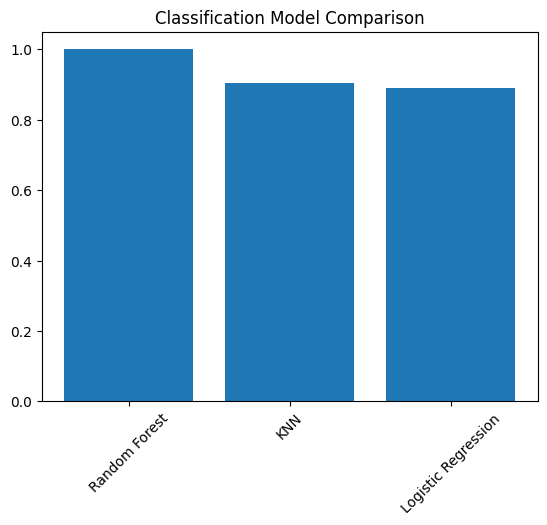

In [ ]:
plt.bar(cls_results_df['Model'], cls_results_df['Accuracy'])
plt.title("Classification Model Comparison")
plt.xticks(rotation=45)
plt.show()

Best Model - Regression

In [ ]:
models_reg = {
    "Linear Regression": best_lr,
    "Random Forest": best_rf_reg,
    "SVR": best_svr
}

results_reg = {
    "Linear Regression": r2_score(y_test_reg, pred_lr),
    "Random Forest": r2_score(y_test_reg, pred_rf_reg),
    "SVR": r2_score(y_test_reg, pred_svr)
}

best_name_reg = max(results_reg, key=results_reg.get)
best_reg = models_reg[best_name_reg]

In [ ]:
reg_results_df = (
    pd.DataFrame(results_reg.items(), columns=['Model', 'R2 Score'])
    .sort_values(by='R2 Score', ascending=False)
    .reset_index(drop=True)
)

print("Best Regression Model:", best_name_reg)
reg_results_df

Best Regression Model: Random Forest


,Model,R2 Score
0,Random Forest,0.829734
1,SVR,0.471397
2,Linear Regression,0.248441


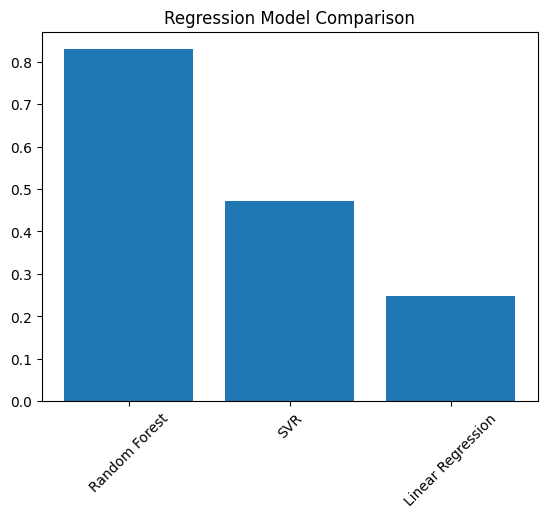

In [ ]:
plt.bar(reg_results_df['Model'], reg_results_df['R2 Score'])
plt.title("Regression Model Comparison")
plt.xticks(rotation=45)
plt.show()

In [ ]:
print("Best Classification Model:", best_cls)
print("Best Regression Model:", best_reg)

Best Classification Model: Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['gender',
                                                   'extracurricular_activities']),
                                                 ('num', StandardScaler(),
                                                  ['ssc_percentage',
                                                   'hsc_percentage',
                                                   'degree_percentage', 'cgpa',
                                                   'entrance_exam_score',
                                                   'technical_skill_score',
                                                   'soft_skill_score',
                                                   'internship_count',
                                                   'live_projects',
         

Confusion Matrix

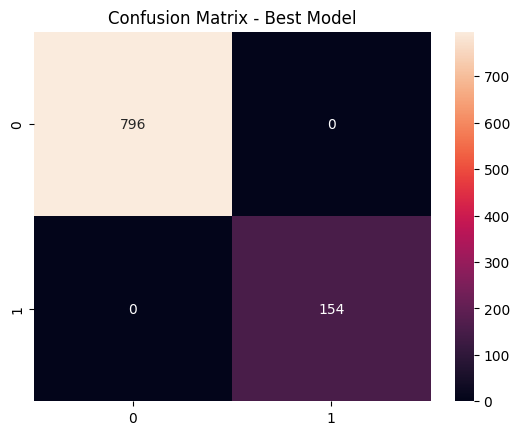

In [ ]:
cm = confusion_matrix(y_test_cls, pred_rf)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Best Model")
plt.show()

---

Final Model

In [ ]:
final_cls_model = best_cls
final_reg_model = best_reg

In [ ]:
type(best_cls)

sklearn.pipeline.Pipeline

**Save Model (.pkl)**

In [ ]:
joblib.dump(final_cls_model, 'classification_model.pkl')

['classification_model.pkl']

In [ ]:
joblib.dump(final_reg_model, 'regression_model.pkl')

['regression_model.pkl']

In [ ]:
files.download("classification_model.pkl")
files.download("regression_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>